# Modelling

## Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import torch
from scripts.hourly_forecasting.data_preparation.data_pipeline import prepare_data_forecasting
from scripts.hourly_forecasting.data_preparation.feature_engineering import construct_features, discard_features
from scripts.hourly_forecasting.models.models import NaiveSimilarDay

## Load and process data

In [3]:
data_path = "../../../data/Hourly_Electricity_Demand_Gen_Weather_Spain/{}.csv";

energy_data_path = data_path.format("energy_dataset");
weather_data_path = data_path.format("weather_features");

energy_data = pd.read_csv(energy_data_path);
weather_data = pd.read_csv(weather_data_path);

data = prepare_data_forecasting(energy_data, weather_data);
data = construct_features(data);
data = discard_features(data);

In [4]:
pd.set_option("display.max_columns", 100);

## Benchmarks

### Naive similar day modelling

In [12]:
data.iloc[int(np.round(data.shape[0] * 0.7)):]

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual,tempValencia,pressureValencia,humidityValencia,wind_speedValencia,wind_degValencia,rain_1hValencia,rain_3hValencia,snow_3hValencia,clouds_allValencia,tempMadrid,pressureMadrid,humidityMadrid,wind_speedMadrid,wind_degMadrid,rain_1hMadrid,rain_3hMadrid,snow_3hMadrid,clouds_allMadrid,tempBilbao,pressureBilbao,humidityBilbao,wind_speedBilbao,wind_degBilbao,rain_1hBilbao,rain_3hBilbao,snow_3hBilbao,clouds_allBilbao,temp Barcelona,pressure Barcelona,humidity Barcelona,wind_speed Barcelona,wind_deg Barcelona,rain_1h Barcelona,rain_3h Barcelona,clouds_all Barcelona,tempSeville,pressureSeville,humiditySeville,wind_speedSeville,wind_degSeville,rain_1hSeville,rain_3hSeville,clouds_allSeville,weekday,hour,total_gen,stable_renewable_gen,renewable_gen,excess_demand,demand_supply_ratio,coverage,excess_coverage,renewables_share,renewable_utilisation_ratio,stable_renewable_utilisation_ratio,renewable_coverage,stable_renewable_coverage,excess_renewable_coverage,excess_stable_renewable_coverage,reserve_margin,capacity_utilisation,renewable_margin,renewable_capacity_utilisation,stable_renewable_margin,stable_renewable_capacity_utilisation
2017-10-19 16:00:00+00:00,317.0,527.0,10056.0,4769.0,319.0,445.0,448.0,815.0,5903.0,60.0,108.0,998.0,298.0,8457.0,678.0,8415.0,30007.0,29732.0,61.84,69.08,292.15,1009,63,3,150,0.3,0.0,0.0,75,291.12,1013,52,5,250,0.0,0.0,0.0,40,292.38,1010,53,2,170,0.0,0.0,0.0,20,289.15,1007,100,5,350,3.0,0.0,90,295.15,1014,60,4,260,0.0,0.0,20,3,18,33520.0,1260.0,11778.0,-3788.0,0.886993,2.418573,-18.983369,0.351372,0.208372,0.050893,1.504978,0.790327,-11.812566,-6.203273,75697.0,0.717990,26792.0,0.473993,-4974.0,-0.200905
2017-10-19 17:00:00+00:00,321.0,560.0,10559.0,4853.0,319.0,155.0,445.0,1508.0,5905.0,60.0,108.0,256.0,301.0,7895.0,202.0,7975.0,31013.0,30957.0,62.58,69.63,291.15,1010,68,2,304,0.0,0.0,0.0,40,290.94,1014,59,5,250,0.0,0.0,0.0,40,290.83,1010,56,1,140,0.0,0.0,0.0,0,289.65,1007,93,4,350,0.9,0.0,75,294.54,1014,64,3,260,0.0,0.0,20,3,19,33245.0,1663.0,10881.0,-2288.0,0.931178,2.331750,-31.548951,0.327297,0.192502,0.067170,1.474400,0.746035,-19.948864,-10.093969,74472.0,0.706371,25567.0,0.452321,-6199.0,-0.250384
2017-10-19 18:00:00+00:00,316.0,564.0,11424.0,5091.0,316.0,0.0,439.0,1615.0,5901.0,60.0,107.0,59.0,302.0,7761.0,108.0,7611.0,32920.0,32728.0,68.12,74.72,291.15,1011,77,1,0,0.0,0.0,0.0,40,289.13,1014,63,4,230,0.0,0.0,0.0,20,288.38,1011,72,2,100,0.0,0.0,0.0,0,290.15,1008,93,4,20,0.9,0.0,76,293.94,1015,60,4,280,0.0,0.0,20,3,20,33955.0,1615.0,10492.0,-1227.0,0.963864,2.183879,-58.251019,0.308997,0.185620,0.065231,1.406502,0.707132,-37.515892,-18.861451,72701.0,0.689573,23796.0,0.420989,-7970.0,-0.321916
2017-10-19 19:00:00+00:00,319.0,592.0,10481.0,4955.0,319.0,0.0,437.0,1615.0,5902.0,59.0,108.0,44.0,305.0,7847.0,68.0,7699.0,31611.0,31680.0,62.65,70.42,290.15,1011,82,1,0,0.0,0.0,0.0,40,287.33,1015,71,2,250,0.0,0.0,0.0,0,286.38,1011,82,1,0,0.0,0.0,0.0,0,290.65,1009,93,4,40,0.0,0.0,76,293.94,1016,60,3,280,0.0,0.0,0,3,21,32983.0,1615.0,10567.0,-1303.0,0.960495,2.286806,-55.599386,0.320377,0.186947,0.065231,1.450663,0.730524,-35.270146,-17.761320,73749.0,0.699513,24844.0,0.439530,-6922.0,-0.279586
2017-10-19 20:00:00+00:00,318.0,611.0,7836.0,4678.0,318.0,28.0,434.0,743.0,5900.0,55.0,108.0,41.0,307.0,7713.0,9.0,7797.0,28676.0,28579.0,58.00,64.97,289.15,1012,82,1,0,0.0,0.0,0.0,20,288.11,1016,67,3,260,0.0,0.0,0.0,0,286.27,1012,72,1,0,0.0,0.0,0.0,0,290.65,1010,93,3,30,0.0,0.0,32,293.15,1017,72,3,270,0.0,0.0,0,3,22,29090.0,771.0,9584.0,-5

In [9]:
data.iloc[int(np.round(data.shape[0] * 0.7)):].shape[0] / data.shape[0] * 100

29.99942961441935

In [12]:
NaiveSimilarDay.initial_data_point(data)

Timestamp('2015-01-12 00:00:00+0000', tz='UTC')

In [14]:
naive_model = NaiveSimilarDay(data.ffill());
naive_model.forecast("2015-01-12")

2015-01-12 00:00:00+00:00    64.89
2015-01-12 01:00:00+00:00    60.91
2015-01-12 02:00:00+00:00    59.68
2015-01-12 03:00:00+00:00    58.04
2015-01-12 04:00:00+00:00    59.57
                             ...  
2018-12-31 18:00:00+00:00    75.30
2018-12-31 19:00:00+00:00    74.95
2018-12-31 20:00:00+00:00    73.16
2018-12-31 21:00:00+00:00    70.39
2018-12-31 22:00:00+00:00    70.20
Name: price actual, Length: 34799, dtype: float64

In [11]:
NaiveSimilarDay.initial_data_point(data.iloc[int(np.round(data.shape[0] * 0.7)):])

Timestamp('2017-10-30 00:00:00+0000', tz='UTC')

In [13]:
naive_model = NaiveSimilarDay(data.ffill().iloc[int(np.round(data.shape[0] * 0.7)):]);
forecasts = naive_model.forecast("2017-10-30");

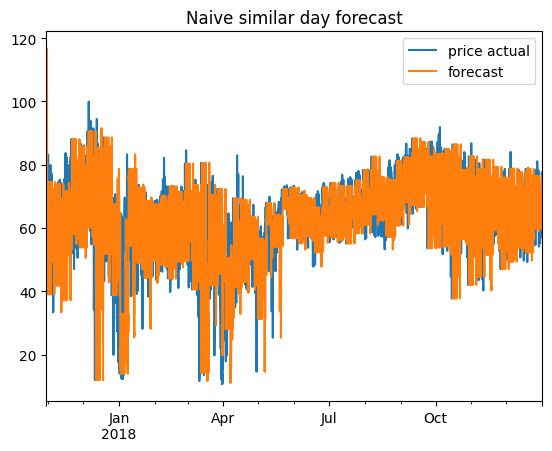

In [21]:
pd.concat([data["price actual"].loc["2017-10-30":], forecasts.rename("forecast")], axis=1).plot(kind="line", title="Naive similar day forecast");

## SARIMA modelling

## Deep Learning time series modelling